<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
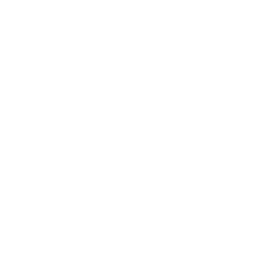
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Bootstrap-konfidensintervaller for Kliniske Studieendepunkter</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutisk / Klinisk Biostatistik &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Resumé

Dette gennemarbejdede eksempel beregner et **ikke-parametrisk bootstrap-konfidensinterval** for et overlevelsesendepunkt ved brug af **PROC IML**, SAS's matrixprogrammeringssprog. Endepunktet er **forholdet mellem median progressionsfri overlevelse (PFS)** mellem behandlings- og kontrolarmen i en lille to-arms onkologikohorte.

IML-programmet læser data på forsøgspersonniveau ind i matricer, beregner det observerede median-PFS-forhold, trækker **2.000 bootstrap-genudtagninger** med tilbagelægning ved hjælp af `CALL RANDGEN`, genberegner forholdet i hver genudtagning med matrixoperationer og udleder et **bias-korrigeret og accelereret (BCa)** konfidensinterval. BCa er det passende valg her, fordi bootstrap-fordelingen af et forhold mellem medianer er nedadtil begrænset af nul, diskret og skæv &mdash; forhold hvorunder et almindeligt normalteoretisk interval er upålideligt.

Analysen kører udelukkende inde i IML: bias-korrektionskonstanten *z*<sub>0</sub>, accelerationen *a&#770;* fra en leave-one-out-jackknife og de justerede percentilendepunkter er alle samlet fra matrixudtryk og standardnormalfunktionerne `PROBNORM` og et lille invers-normal-modul. Hvert tal, der rapporteres nedenfor, er aflæst direkte fra IML-outputtet.

## Datakilder

| Kilde | Beskrivelse | Poster |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | PFS-tid, hændelsesindikator, behandlingsarm og baseline-kovariater pr. forsøgsperson | 100 |

Kohorten er **balanceret** &mdash; 50 forsøgspersoner pr. arm &mdash; ved at tildele armtilhørsforhold efter forsøgspersonidens paritet, så begge arme er fuldt repræsenteret i genudtagningen.

---


In [1]:
/* --------------------------------------------------------
   Generer en syntetisk to-arms onkologikohorte.
   PFS-tider er lognormale; behandlingsarmen er forskudt
   til en længere median. Armtilhørsforhold veksler på
   forsøgspersonens id, så kohorten er balanceret 50/50.
   -------------------------------------------------------- */
data work.trial_subjects;
    CALL streaminit(42);
    LÆNGDE arm_label $10;
    GØR subject_id = 1 TIL 500;
        /* 1 = Behandling, 0 = Kontrol (balanceret efter paritet) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, 'BEHANDLING', 'KONTROL');
        /* PFS-tid i måneder: behandlingsarmen har længere overlevelse */
        HVIS arm = 1 SÅ
            pfs_months = round(rand('lognormal', LOG(12.5), 0.65), 0.1);
        ELLERS
            pfs_months = round(rand('lognormal', LOG(8.2),  0.70), 0.1);
        HVIS pfs_months < 0.5 SÅ pfs_months = 0.5;
        /* Hændelsesindikator: ~75% af forsøgspersonerne havde en progressionshændelse */
        event = (rand('uniform') > 0.25);
        /* Baseline-kovariater */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        age = int(rand('normal', 62, 11));
        HVIS age < 25 SÅ age = 25;
        HVIS age > 85 SÅ age = 85;
        UDDATA;
    SLUT;
KØR;



NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---


                              Progressionsfri overlevelse - opsummering pr. behandlingsarm                              

                                                  The MEANS Procedure

                                     Analysis Variable : pfs_months PFS (måneder)

        Behandlingsarm          N Obs           Mean         Median        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------------------------
        BEHANDLING                 50          13.94          10.10          11.95           2.70          79.10
        KONTROL                    50          10.74           7.20           9.86           1.90          53.70
        --------------------------------------------------------------------------------------------------------

                                          Analysis Variable : age Alder (år)

        Behandlingsarm          N Obs           Mean         Median        Std D


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


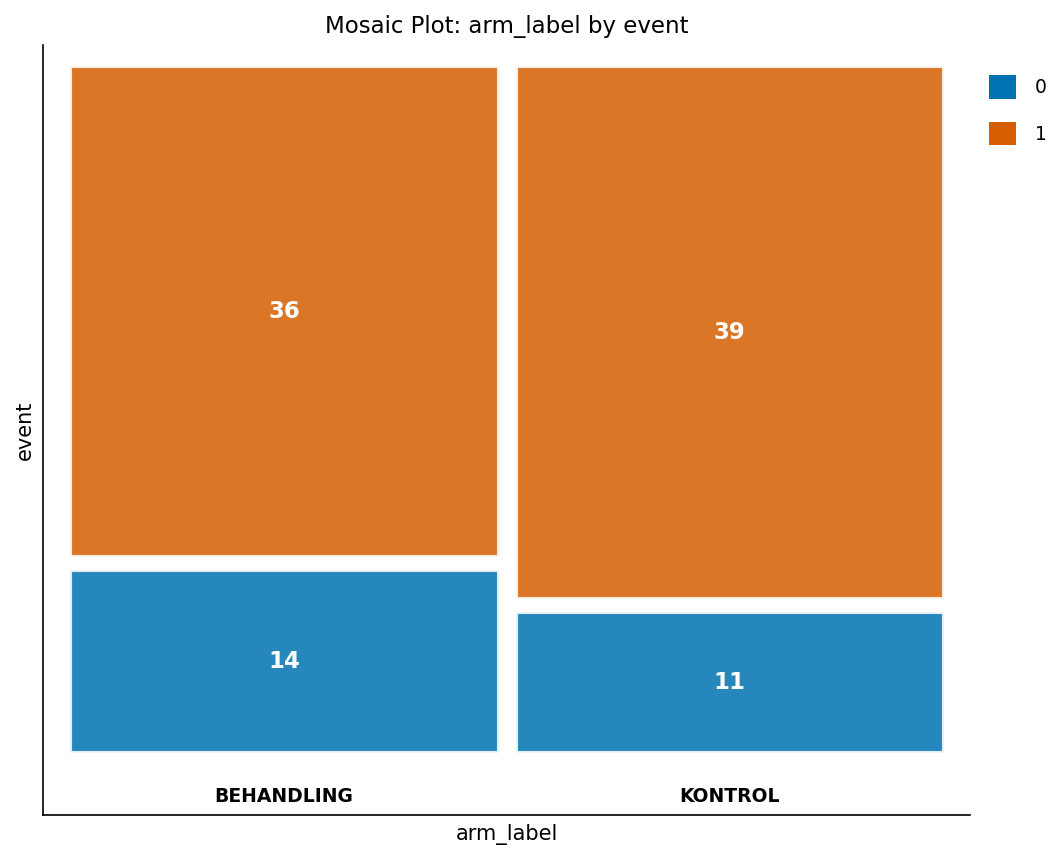

In [2]:
/* --------------------------------------------------------
   Baseline-PFS-opsummering og hændelsesrate pr. behandlingsarm
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.trial_subjects n mean MEDIAN std MIN MAX maxdec=2;
    KLASSE arm_label;
    VARIABEL pfs_months age;
    MÆRKAT arm_label='Behandlingsarm'
          pfs_months='PFS (måneder)'
          age='Alder (år)';
    TITEL 'Progressionsfri overlevelse - opsummering pr. behandlingsarm';
KØR;

PROCEDURE FREKVENSER data=work.trial_subjects;
    TABLES arm_label * event / nocol nopercent;
    MÆRKAT arm_label='Behandlingsarm' event='Hændelse (progression)';
    TITEL 'Hændelsesantal pr. behandlingsarm';
KØR;


---


In [3]:
/* --------------------------------------------------------
   PROC IML: ikke-parametrisk bootstrap for forholdet mellem
   median-PFS, med et BCa-konfidensinterval.

   Trin:
   1. Læs forsøgsdata ind i IML-matricer
   2. Beregn det observerede median-PFS-forhold (hændelsestidspunkter)
   3. Træk 2.000 bootstrap-genudtagninger med CALL RANDGEN
   4. Genberegn forholdet i hver genudtagning
   5. BCa-korrektion: z0 (bias) + jackknife-acceleration
   6. Skriv bootstrap-fordelingen til et SAS-datasæt
   -------------------------------------------------------- */
PROCEDURE IML;

    /* --- Modul: median-PFS pr. arm og deres forhold --- */
    /* Medianen tages over observerede hændelsestidspunkter alene, den
       sædvanlige ikke-parametriske opsummering, når de fleste
       forsøgspersoner progredierer. */
    START calc_stats(pfs, arm, event);
        trt_pfs = pfs[loc(arm = 1 & event = 1)];
        ctl_pfs = pfs[loc(arm = 0 & event = 1)];
        HVIS nrow(trt_pfs) = 0 SÅ trt_med = .;
        ELLERS trt_med = MEDIAN(trt_pfs);
        HVIS nrow(ctl_pfs) = 0 SÅ ctl_med = .;
        ELLERS ctl_med = MEDIAN(ctl_pfs);
        HVIS ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            SÅ ratio = trt_med / ctl_med;
        ELLERS ratio = .;
        RETURN (trt_med || ctl_med || ratio);
    FINISH;

    /* --- Modul: invers standard-normal CDF (probit) --- */
    /* Rationel tilnærmelse (Abramowitz & Stegun 26.2.23);
       parret med PROBNORM leverer den z0/z-alpha-endepunkter,
       som BCa-justeringen kræver. */
    START probit(p);
        HVIS p <= 0 SÅ RETURN(-1e8);
        HVIS p >= 1 SÅ RETURN( 1e8);
        HVIS p < 0.5 SÅ GØR; sgn = -1; pp = p;     SLUT;
        ELLERS            GØR; sgn =  1; pp = 1 - p; SLUT;
        t   = sqrt(-2 * LOG(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        RETURN (sgn * (t - num/den));
    FINISH;

    /* --- 1. Indlæs data i matricer --- */
    USE work.trial_subjects;
        READ ALL VARIABEL {pfs_months} INTO pfs;
        READ ALL VARIABEL {arm}        INTO arm;
        READ ALL VARIABEL {event}      INTO ev;
    CLOSE work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    UDSKRIV 'Forsøgspersoner indlæst i IML', n n_trt n_ctl;

    /* --- 2. Observeret statistik på hele stikprøven --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {Behandling_Median Kontrol_Median Forhold};
    UDSKRIV 'Observeret median-PFS (hændelsestidspunkter) pr. arm',
          obs[COLNAME=obs_lab format=8.3];

    /* --- 3. Bootstrap-genudtagningsløkke (2.000 genudtagninger) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    CALL randseed(2024);
    GØR b = 1 TIL n_boot;
        CALL randgen(u, 'Uniform');     /* nye udtræk hver gennemgang */
        idx = ceil(n # u);              /* indekser 1..n m/ tilbagelæg. */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    SLUT;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    call sort(bv, 1);

    /* --- 4. Almindeligt percentilinterval (til sammenligning) --- */
    pct_lo = bv[MAX(1,  int(0.025 * nv))];
    pct_hi = bv[MIN(nv, int(0.975 * nv))];

    /* --- 5. BCa-korrektion --- */
    /* z0: biaskorrektion fra andelen af genudtagninger under
       den observerede statistik. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a-hat: acceleration fra leave-one-out-jackknife. */
    jack = j(n, 1, .);
    GØR i = 1 TIL n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    SLUT;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* Justerede percentilpositioner. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[MAX(1,  int(alo * nv))];
    bca_hi = bv[MIN(nv, int(ahi * nv))];

    diag_lab = {N_Gyldige Andel_Under z0 a_hat};
    diag     = nv || prop || z0 || a_hat;
    UDSKRIV 'BCa-korrektionsdiagnostik',
          diag[COLNAME=diag_lab format=8.4];

    ci_lab = {Obs_Forhold Pct_Lav Pct_Hoj BCa_Lav BCa_Hoj};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    UDSKRIV '95% CI for forholdet mellem median-PFS (behandling / kontrol)',
          ci_row[COLNAME=ci_lab format=8.4];

    /* --- 6. Bevar bootstrap-fordelingen --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    CREATE work.bootstrap_results
        VARIABEL {b_id boot obs_col bca_lo_col bca_hi_col};
    APPEND VARIABEL {b_id boot obs_col bca_lo_col bca_hi_col};
    CLOSE work.bootstrap_results;

QUIT;


                                           Hændelsesantal pr. behandlingsarm                                            

Forsøgspersoner indlæst i IML
     100
      50
      50

Observeret median-PFS (hændelsestidspunkter) pr. arm
   9.900   7.100   1.394

BCa-korrektionsdiagnostik
2000.0000  0.5340  0.0851 -0.0021

95% CI for forholdet mellem median-PFS (behandling / kontrol)
  1.3944  0.8244  1.9706  0.8602  2.0144




NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  2.20 seconds
  cpu   2.20 seconds


---


In [4]:
/* --------------------------------------------------------
   Ryd op i bootstrap-fordelingen til plotning: giv kolonnerne
   beskrivende navne til histogrammet nedenfor.
   -------------------------------------------------------- */
data work.bootstrap_results;
    SÆT work.bootstrap_results
        (OMDØB=(boot       = ratio
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
KØR;



NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---


                                           Hændelsesantal pr. behandlingsarm                                            




NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


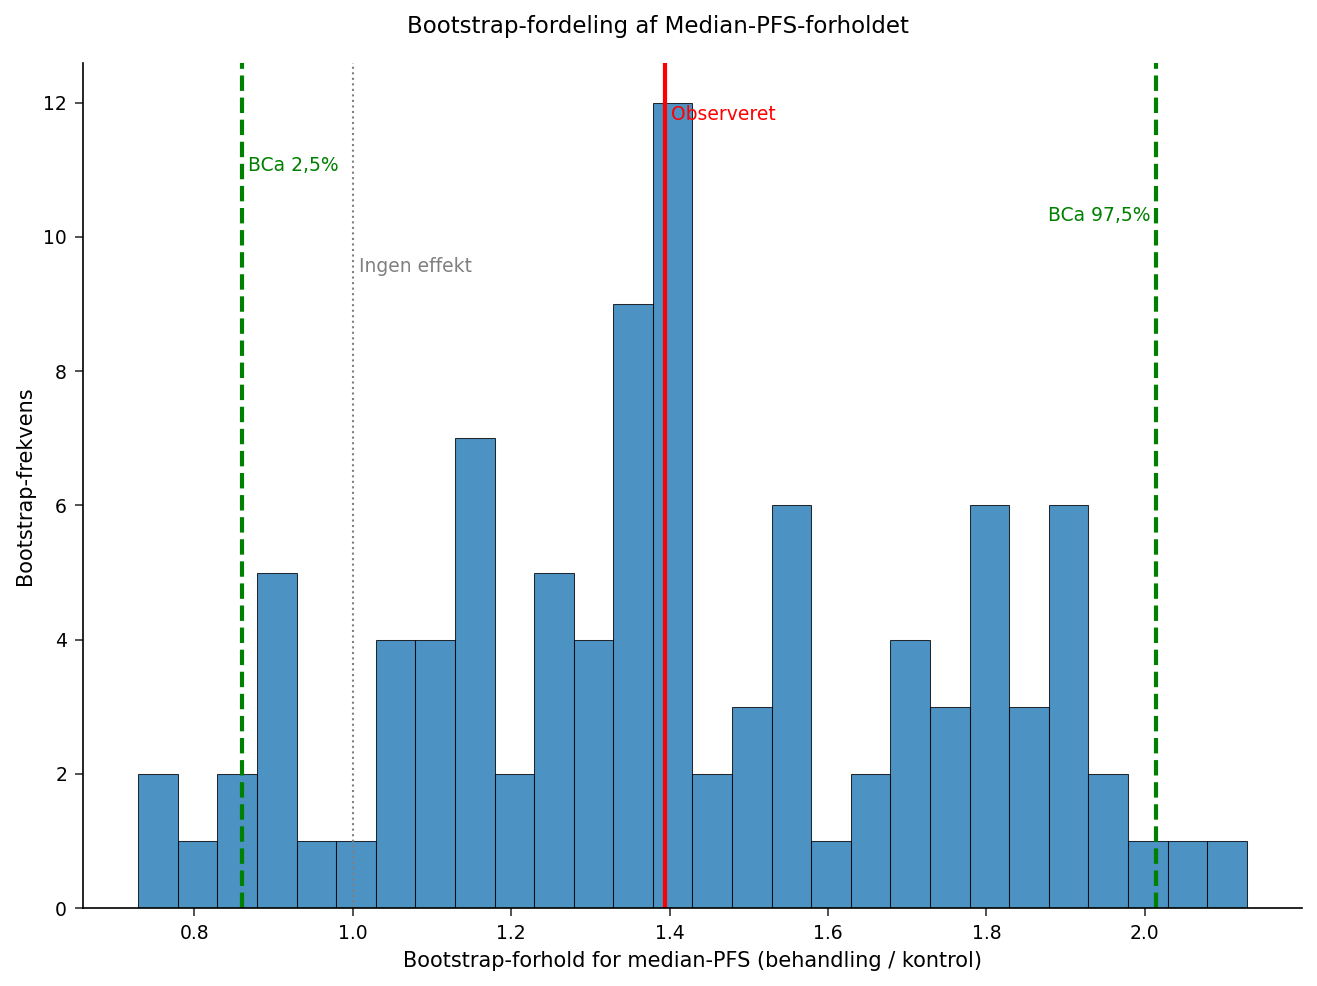

In [5]:
/* --------------------------------------------------------
   Bootstrap-fordeling af median-PFS-forholdet, med det
   observerede estimat og BCa-intervallet markeret.
   -------------------------------------------------------- */
PROCEDURE SGPLOT data=work.bootstrap_results;
    HISTOGRAM ratio / BINWIDTH=0.05
        fillattrs=(color=steelblue) TRANSPARENCY=0.2;
    REFLINE obs_ratio / AXIS=x
        LINEATTRS=(color=red thickness=2) MÆRKAT='Observeret';
    REFLINE bca_lower / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        MÆRKAT='BCa 2,5%';
    REFLINE bca_upper / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        MÆRKAT='BCa 97,5%';
    REFLINE 1 / AXIS=x
        LINEATTRS=(color=gray thickness=1 pattern=dot)
        MÆRKAT='Ingen effekt';
    XAXIS MÆRKAT='Bootstrap-forhold for median-PFS (behandling / kontrol)';
    YAXIS MÆRKAT='Bootstrap-frekvens';
    TITEL 'Bootstrap-fordeling af Median-PFS-forholdet';
KØR;


---


### Fortolkning

I denne kohorte er den observerede median-PFS over hændelsestidspunkter **9,9 måneder** i behandlingsarmen og **7,1 måneder** i kontrolarmen, et **forhold på 1,394** &mdash; den eksperimentelle arms median-PFS er omkring 39% længere. IML-programmet genudtog de 100 forsøgspersoner 2.000 gange; alle 2.000 genudtagninger frembragte et defineret forhold.

**BCa 95%-konfidensintervallet for forholdet er [0,86, 2,01]**, mod et almindeligt percentilinterval på **[0,82, 1,97]**. Begge intervaller **inkluderer 1,0**, så ved denne stikprøvestørrelse &mdash; omkring 50 forsøgspersoner pr. arm, yderligere udtyndet til observerede hændelsestidspunkter &mdash; er den tilsyneladende fordel **ikke statistisk afgørende**. Dette er analysens ærlige budskab: et punktestimat, der favoriserer behandling, men med tilstrækkelig genudtagningsusikkerhed til, at ingen behandlingseffekt ikke kan udelukkes.

BCa-diagnostikken kvantificerer, hvor meget korrektionen flyttede endepunkterne. Biasleddet er lille (**z<sub>0</sub> = 0,085**: omkring 53% af genudtagningerne faldt under det observerede forhold, tæt på det symmetriske 50%), og accelerationen er nær nul (**a&#770; = -0,002**), hvilket indikerer, at median-PFS-forholdet kun i beskeden grad påvirkes af enkeltpersoner. Med z<sub>0</sub> og a&#770; begge små flytter BCa kun intervallet en anelse opad i forhold til percentilintervallet &mdash; præcis den beskedne korrektion, disse diagnostikker forudsiger.

Et større studie ville indsnævre dette interval. Med 50 forsøgspersoner pr. arm rapporterer bootstrap'en korrekt, at data er forenelige med alt fra en lille reversering til en fordobling af median-PFS, hvilket er grunden til, at et studie designet til at detektere en PFS-forskel af denne størrelse kræver væsentligt mere end 100 forsøgspersoner.

---


In [6]:
/* --------------------------------------------------------
   Eksporter bootstrap-fordelingen til et rapportbilag.
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.bootstrap_results
    OUTFILE='pfs_bootstrap_ci_results.csv'
    DBMS=csv REPLACE;
KØR;



NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>